# Assignment 2

### Dominik Hołoś
### Maria Nowacka

### 2.2 LIME for Image Classification (25 points)
Use a pre-trained ResNet model on ImageNet:
* Select 5 images from different classes.
* Apply LIME to explain each prediction.
* Visualize superpixels that contribute most to predictions.
* Discuss whether explanations align with human intuition


In [9]:
!pip install transformers datasets

  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached xxhash-3.6.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (13 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (20 kB)
  Using cached propcache-0.4.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (13 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 581.9 kB/s  0:00:17 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 2.9 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 776.2 kB/s  0:00:04 eta 0:00:01
Using cached httpx-0.2

In [10]:
import torch, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
from PIL import Image
from torchvision import models, transforms
from lime import lime_image
from skimage.segmentation import mark_boundaries
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
warnings.filterwarnings('ignore')

In [7]:
#1. load the pre-trained ResNet model (ResNet18)
weights = models.ResNet18_Weights.DEFAULT #you can also try ResNet50: larger but slower
model = models.resnet18(weights=weights)
model.eval()
categories = weights.meta["categories"]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/marysia/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:24<00:00, 1.90MB/s]


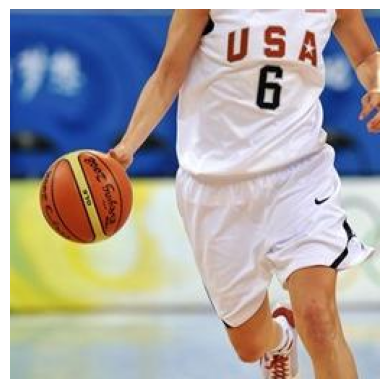

In [10]:
#2. load the image
img_path = '/Users/marysia/Desktop/applied/ml/assignment2_intro_notebooks/155.jpg'
img = Image.open(img_path).convert('RGB')

plt.figure()
plt.imshow(img)
plt.axis('off')
plt.show()

In [11]:
#3. preprocess the image
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

input_img = preprocess(img).unsqueeze(0)

In [14]:
#4. make a prediction (true class: basketball)
with torch.no_grad():
    output = model(input_img)
    probabilities = F.softmax(output[0], dim=0)

top5_prob, top5_indices = torch.topk(probabilities, 5)
print("Top 5 Predictions:")
for i in range(5):
    label = categories[top5_indices[i]]
    confidence = top5_prob[i].item() * 100
    print(f"{i+1}. {label:<20} {confidence:.2f}%")

Top 5 Predictions:
1. basketball           99.94%
2. volleyball           0.05%
3. racket               0.00%
4. barbell              0.00%
5. soccer ball          0.00%


In [15]:
#5. get lime explanations
explainer = lime_image.LimeImageExplainer(random_state=42)

def predict_fn(images):
    batch = torch.stack([preprocess(Image.fromarray(im.astype(np.uint8))) for im in images])
    with torch.no_grad():
        probs = F.softmax(model(batch), dim=1)
    return probs.numpy()

img_array = np.array(img.resize((224, 224)))  # lime needs a numpy array

explanation = explainer.explain_instance(
    img_array,
    predict_fn,
    top_labels=5,
    num_samples=1000, # higher = more accurate but slower
    random_seed=42
)

100%|██████████| 1000/1000 [00:28<00:00, 35.65it/s]


Explaining class: basketball


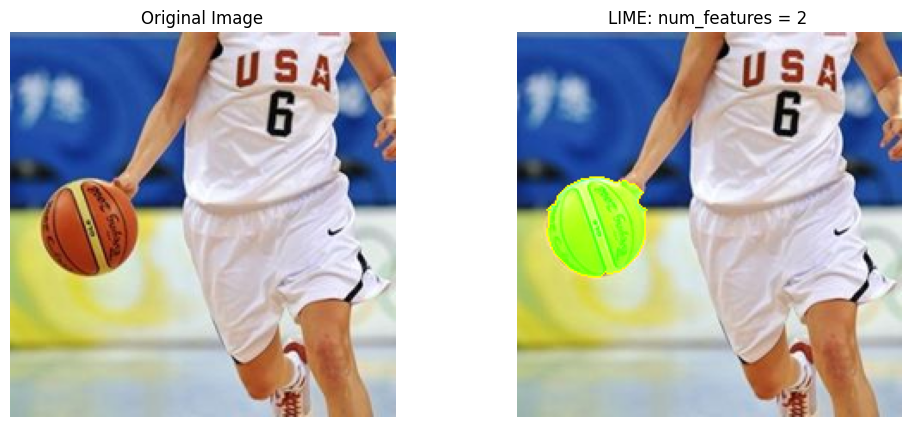

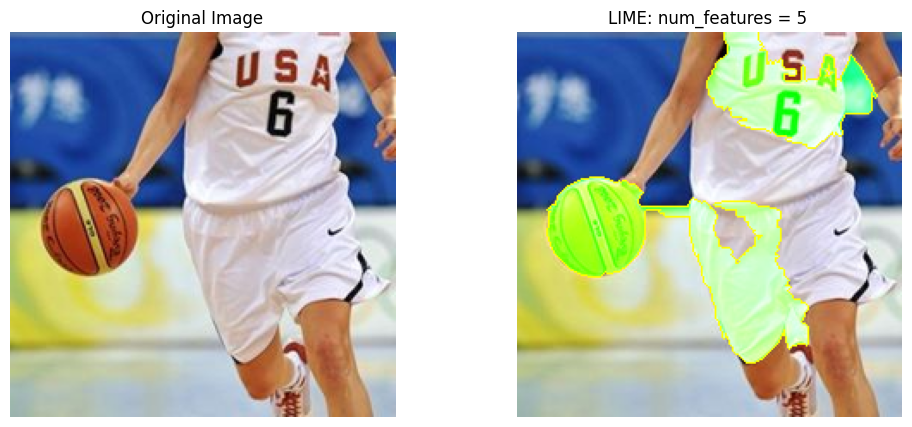

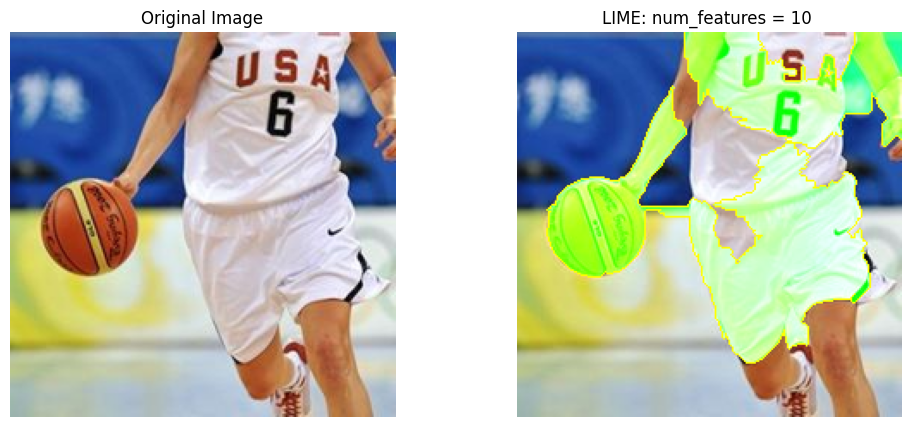

In [19]:
#6. visualize the explanation
top_class = explanation.top_labels[0]
print(f"Explaining class: {categories[top_class]}")

for nf in [2,5,10]: #for different numbers of highlighted superpixels (num_features)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    #left: original image
    axes[0].imshow(img_array)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    #right: LIME explanation
    explained_img, mask = explanation.get_image_and_mask(
        top_class,
        positive_only=False,
        num_features=nf,
        hide_rest=False
    )
    axes[1].imshow(mark_boundaries(explained_img / 255.0, mask))
    axes[1].set_title("LIME: num_features = %d " % nf)
    axes[1].axis("off")

#green = supports prediction, red = contradicts

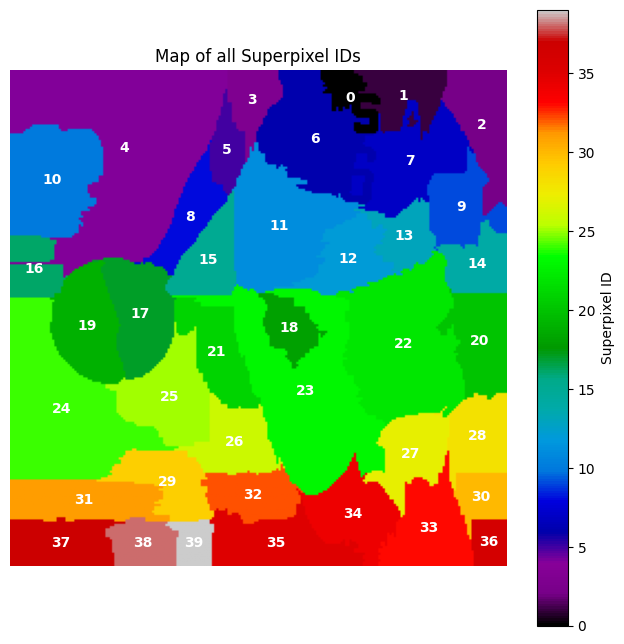

In [20]:
#7. extra stuff: map of all superpixels
segments = explanation.segments
plt.figure(figsize=(8, 8))
plt.imshow(segments, cmap='nipy_spectral')
plt.colorbar(label="Superpixel ID")
plt.title("Map of all Superpixel IDs")

for label in np.unique(segments):
    y, x = np.where(segments == label)
    plt.text(x.mean(), y.mean(), str(label),
             color='white', weight='bold', ha='center', va='center')

plt.axis('off')
plt.show()

In [21]:
#8. extra stuff: importance weights for all superpixels
dict_heatmap = explanation.local_exp[top_class]
print("Feature ID | Importance Weight")
print("----------------------------")
for feature_id, weight in dict_heatmap[:10]: #top 10 most important superpixels
    print(f"{feature_id:^10} | {weight:.4f}")

Feature ID | Importance Weight
----------------------------
    17     | 0.3370
    19     | 0.3360
    6      | 0.2729
    7      | 0.1590
    23     | 0.1574
    2      | 0.1491
    8      | 0.0989
    3      | 0.0981
    12     | 0.0973
    22     | 0.0969


In [ ]:
# ...existing code...
import os
from pathlib import Path

# ...existing code...
# --- NEW CELL: Run LIME on 5 images and visualize top contributing superpixels ---

image_dir = '/Users/marysia/Desktop/applied/ml/assignment2_intro_notebooks'
# collect image paths (use first 5 images found). Replace with explicit paths if you prefer.
img_files = sorted([str(Path(image_dir) / f) for f in os.listdir(image_dir)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

if len(img_files) < 5:
    raise RuntimeError(f"Need at least 5 images in {image_dir}, found {len(img_files)}.")

selected_paths = img_files[:5]  # select first 5 (ensure they are from different classes if possible)

explainer = lime_image.LimeImageExplainer(random_state=42)

def predict_fn(images):
    # images: list/array of HxWx3 uint8
    batch = torch.stack([preprocess(Image.fromarray(im.astype(np.uint8))) for im in images]).to('cpu')
    with torch.no_grad():
        out = model(batch)
        probs = F.softmax(out, dim=1).cpu().numpy()
    return probs

def visualize_explanation(explanation, img_array, top_class, categories, top_k=3, num_features=10):
    # show original and LIME mask (positive contributions) and overlay top_k superpixels
    plt.figure(figsize=(12,5))

    plt.subplot(1,3,1)
    plt.imshow(img_array)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    explained_img_pos, mask_pos = explanation.get_image_and_mask(
        top_class, positive_only=True, num_features=num_features, hide_rest=False
    )
    plt.imshow(mark_boundaries(explained_img_pos/255.0, mask_pos))
    plt.title("LIME (positive superpixels)")
    plt.axis('off')

    # build overlay of top_k contributing superpixels by weight
    segs = explanation.segments
    exp_map = dict(explanation.local_exp[top_class])  # list of (superpixel_id, weight)
    # select top_k positive superpixels
    pos_feats = sorted([ (fid, w) for fid,w in exp_map.items() if w>0 ],
                       key=lambda x: -x[1])[:top_k]
    mask = np.zeros(segs.shape, dtype=bool)
    for fid, w in pos_feats:
        mask[segs == fid] = True

    overlay = img_array.copy().astype(float) / 255.0
    # dim non-selected regions
    overlay[~mask] *= 0.25

    plt.subplot(1,3,3)
    plt.imshow(mark_boundaries(overlay, mask))
    plt.title(f"Top {top_k} contributing superpixels")
    plt.axis('off')

    plt.suptitle(f"Predicted: {categories[top_class]}")
    plt.show()

# loop through 5 images
for p in selected_paths:
    img = Image.open(p).convert('RGB')
    img_array = np.array(img.resize((224,224)))
    # predict top5
    preds = predict_fn([img_array])[0]
    top5_idx = preds.argsort()[-5:][::-1]
    print("\nImage:", p)
    for i, idx in enumerate(top5_idx, 1):
        print(f"{i:>2}. {categories[idx]:<30} {preds[idx]*100:6.2f}%")

    # explain top predicted class
    explanation = explainer.explain_instance(
        img_array,
        predict_fn,
        top_labels=5,
        num_samples=1000,
        random_seed=42
    )
    top_class = explanation.top_labels[0]
    visualize_explanation(explanation, img_array, top_class, categories, top_k=3, num_features=10)

# ...existing code...

### 2.4 Attention Visualization (20 points)
Use a pre-trained BERT model for sentiment analysis:
* Analyze movie reviews from IMDB.
* Visualize attention weights for 5 reviews.
* Identify which words contribute most to sentiment predictions.
* Compare attention patterns for positive vs. negative reviews.

In [ ]:
#1. Load the BERT model (pre-trained for sentiment analysis) with its tokenizer
#here, we use the distilled (smaller) version of BERT model
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, output_attentions=True)

In [ ]:
#2. Prepare the input
text = "The acting was incredible, but the script was absolutely terrible."
inputs = tokenizer(text, return_tensors="pt",truncation=True, max_length=512) #truncation and max_length: for handling BERT limits for longer inputs
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
#3. Forward pass
with torch.no_grad():
    outputs = model(**inputs)
    attentions = outputs.attentions
#4. Get the sentiment prediction
logits = outputs.logits
probs = F.softmax(logits, dim=-1)
prediction_idx = torch.argmax(probs).item()
label = model.config.id2label[prediction_idx]
confidence = probs[0][prediction_idx].item()
print(f"Sentiment: {label}")
print(f"Confidence: {confidence:.2%}")

In [ ]:
#5. Visualize the attention weights from last layer, first head

head = 0 #0,...,11
attention_matrix = attentions[-1][0, head].detach().numpy() #-1 denotes the last layer (distilbert has 6 layers, 12 heads)

plt.figure(figsize=(10, 8))
sns.heatmap(attention_matrix, xticklabels=tokens, yticklabels=tokens,
            annot=False, cmap="viridis")
plt.title(f"Attention Weights (Last layer, head {head+1})")
plt.xlabel("Key (Attended to)")
plt.ylabel("Query (Attending)")
plt.show()
#We look at the values in the first row (to which tokens does the [CLS] token attend the most)

In [ ]:
#6. Calculate average attention for [CLS] token and all heads
last_layer = attentions[-1][0]
avg_attn = last_layer.mean(dim=0)
cls_attention = avg_attn[0].detach().numpy()

plt.figure(figsize=(10, 4))
x_pos = range(len(tokens))
sns.barplot(x=x_pos, y=cls_attention, palette="magma")
plt.title("Importance Score: How much the [CLS] token attended to each word")
plt.xticks(x_pos, tokens, rotation=45, ha="right")
plt.ylabel("Attention Weight")
plt.show()

In [ ]:
#7. quick IMDb example
imdb_test = load_dataset("imdb", split="test")

In [ ]:
review = imdb_test[2] #a single review: text and label
review